# PRÁCTICA CERO: ANATOMÍA Y ANÁLISIS DE UN DATASET

1. Objetivo
2. Fase 1: Análisis de Casos (Búsqueda vs. Creación)
3. Fase 2: Análisis Exploratorio de Datos (EDA) con Python
4. Fase 3: Entregable y Conclusiones Críticas

## 1. Objetivo

Desarrollar criterio analítico para diferenciar entre la obtención pasiva de datos (búsqueda), la instrumentación activa (creación) y el Análisis Exploratorio de Datos (EDA).

## 2. Fase 1: Análisis de Casos (Búsqueda vs. Creación)


Los alumnos deben discutir y contrastar metodologías de obtención de datos mediante dos escenarios de ingeniería.

• *Escenario A (Búsqueda e Integración):* Se requiere predecir la demanda eléctrica en Michoacán para el próximo mes. Los datos ya existen de forma pública (ej. reportes del CENACE o bases meteorológicas).

• *Reto principal*: Limpieza de datos (data wrangling), alineación de diferentes fuentes (cruzar temperaturas con MW/h), manejo de valores nulos (NaN) y resolución temporal inconsistente.

• *Escenario B (Creación e Instrumentación):* Se requiere predecir el comportamiento térmico de una estructura metálica específica mientras es sometida a soldadura o estrés mecánico. No existe un dataset en internet para esta pieza exacta.

• *Reto principal*: Adquisición de señales. Implica seleccionar hardware (termopares), definir la frecuencia de muestreo, lidiar con el ruido electromagnético de la máquina de soldar y asegurar la fidelidad física del dato.

## 3. Fase 2: Análisis Exploratorio de Datos (EDA) con Python

Una vez comprendido el origen, los alumnos deben realizar un "Sanity Check" a un dataset. Se les proporcionará un script base para analizar una serie de tiempo sintética (o real, si ya cuentan con una) antes de siquiera pensar en Keras o PyTorch.

*Instrucción:* Ejecutar el siguiente script para realizar una inspección estadística y visual de la señal. El alumno debe modificar el código para inyectar anomalías intencionales y ver cómo se reflejan en las métricas.

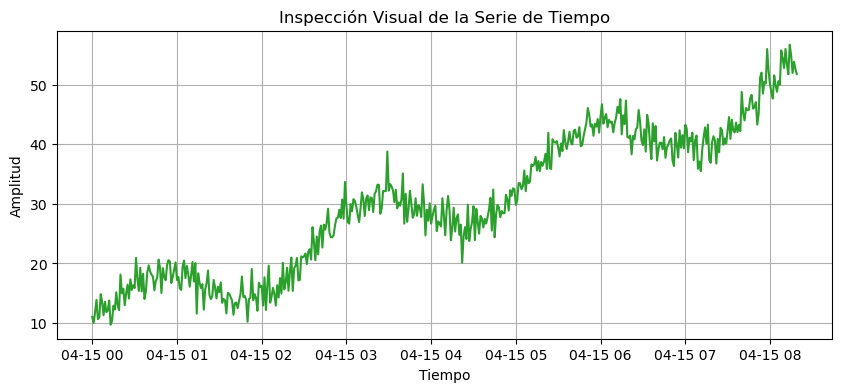

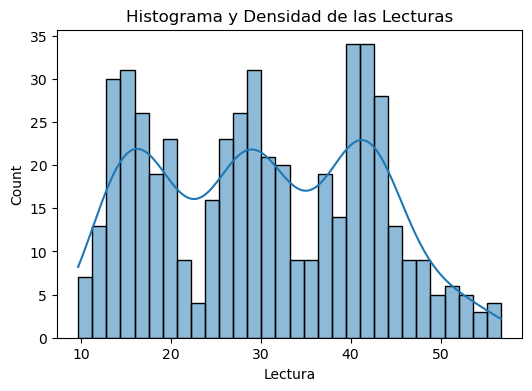

=== Perfil Estadístico del Dataset ===
          Lectura
count  500.000000
mean    30.165904
std     11.761739
min      9.704445
25%     19.040571
50%     29.669652
75%     40.621295
max     56.712650


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Generación/Carga de Datos (Simulando un sensor con ruido y tendencia)
np.random.seed(42)
# Usamos una ventana de tiempo representativa
tiempo = pd.date_range(start='2026-04-15', periods=500, freq='min')

# Señal: Tendencia base + oscilación + ruido gaussiano
valores = np.linspace(10, 50, 500) + np.sin(np.linspace(0, 20, 500))*5 + np.random.normal(0, 2, 500)

df = pd.DataFrame({'Timestamp': tiempo, 'Lectura': valores})
df.set_index('Timestamp', inplace=True)

# 2. Inspección Temporal (¿Hay valores atípicos o estacionalidad?)
plt.figure(figsize=(10, 4))
plt.plot(df.index, df['Lectura'], label='Señal Cruda del Sensor', color='#2ca02c')
plt.title("Inspección Visual de la Serie de Tiempo")
plt.xlabel("Tiempo")
plt.ylabel("Amplitud")
plt.grid(True)
plt.show()

# 3. Análisis de Distribución (¿El ruido es normal?)
plt.figure(figsize=(6, 4))
sns.histplot(df['Lectura'], kde=True, bins=30)
plt.title("Histograma y Densidad de las Lecturas")
plt.show()

# 4. Estadística Descriptiva (El perfil del dataset)
print("=== Perfil Estadístico del Dataset ===")
print(df.describe())

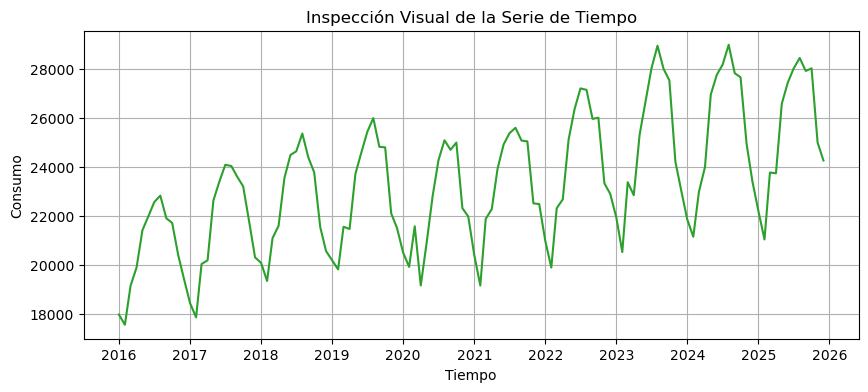

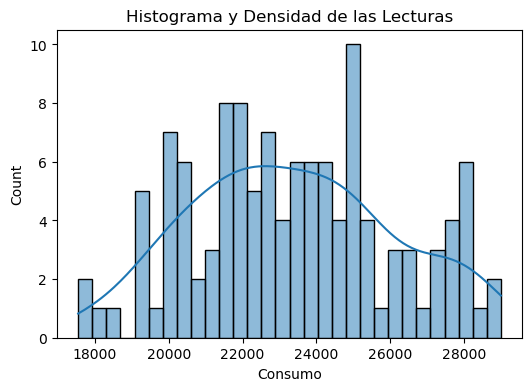

=== Perfil Estadístico del Dataset ===
            Consumo
count    120.000000
mean   23349.779810
std     2735.711575
min    17543.355760
25%    21487.014490
50%    23265.049505
75%    25079.973435
max    28999.671230


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('consumo_final_energia_electrica.csv')

df['Timestamp'] = pd.to_datetime(df['fecha'])
df.set_index('Timestamp', inplace=True)
df.rename(columns={'consumo_final_electricidad_gwh': 'Consumo'}, inplace=True)

# 2. Inspección Temporal (¿Hay valores atípicos o estacionalidad?)
plt.figure(figsize=(10, 4))
plt.plot(df.index, df['Consumo'], label='Señal Cruda del Sensor', color='#2ca02c')
plt.title("Inspección Visual de la Serie de Tiempo")
plt.xlabel("Tiempo")
plt.ylabel("Consumo")
plt.grid(True)
plt.show()

# 3. Análisis de Distribución (¿El ruido es normal?)
plt.figure(figsize=(6, 4))
sns.histplot(df['Consumo'], kde=True, bins=30)
plt.title("Histograma y Densidad de las Lecturas")
plt.show()

# 4. Estadística Descriptiva (El perfil del dataset)
print("=== Perfil Estadístico del Dataset ===")
print(df.describe())

## 4. Fase 3: Entregable y Conclusiones Críticas


Basándose en la ejecución del código y el análisis de las gráficas, el alumno debe redactar un reporte en su entorno de trabajo (Jupyter) respondiendo:

1. Observando la gráfica temporal: ¿La serie de tiempo es estacionaria (su media y varianza son constantes)? ¿Por qué esto es un factor crítico antes de entrenar un modelo predictivo?

- No lo es. Ignorarlo llevaría a modelos que extrapolan tendencias fuera del rango físico.

2. En el mundo real, si tú hubieras construido el circuito para capturar este dataset (Escenario B), ¿qué factores físicos del entorno podrían generar "picos" atípicos (outliers) en las lecturas?

- Los picos pueden deberse a (a) ruido electromagnético del arco, (b) micro-despegues del termopar, (c) overshoot térmico. Para distinguirlos de errores, se recomienda un segundo termopar y registrar la corriente de soldadura.

3. ¿Qué riesgos corremos como ingenieros si saltamos esta fase de análisis y conectamos directamente estos datos crudos a una Red Neuronal?

- El principal peligro es el *sobreajuste al ruido del sensor*, que colapsa en producción cuando cambia cualquier variable del entorno (operario, máquina, temperatura ambiente). Un análisis exploratorio robusto es obligatorio antes de cualquier modelo supervisado.